# Model Training — Three Classifiers <a id="7"></a>

We train three classifiers of increasing complexity:

| Model | Strength | Weakness |
|-------|----------|----------|
| **Logistic Regression** | Fast, interpretable, good baseline | Assumes linear decision boundary |
| **Random Forest** | Handles non-linearity, robust to outliers | Slower, can overfit with deep trees |
| **XGBoost** | State-of-the-art on tabular data, built-in regularisation | More hyperparameters to tune |

All models are trained on the SMOTE-balanced training set. Evaluation is done on the untouched held-out test set.

## Setup & Import

In [16]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score, f1_score,
    precision_score, recall_score
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# Style settings
DARK = {
    "bg": "#0F1117", "panel": "#1A1D27", "grid": "#252836",
    "text": "#E8EAF0", "sub": "#8890A4", "blue": "#4F8EF7",
    "red": "#F7614F", "green": "#4FD1A5", "gold": "#F7C84F", "purple": "#A78BFA",
}

plt.rcParams.update({
    "figure.facecolor": DARK["bg"], "axes.facecolor": DARK["panel"],
    "axes.edgecolor": DARK["grid"], "axes.labelcolor": DARK["text"],
    "xtick.color": DARK["sub"], "ytick.color": DARK["sub"],
    "figure.dpi": 110,
})

SEED = 42
np.random.seed(SEED)

## Load data

In [4]:
df = pd.read_csv("data/data_feature_engineered.csv")
FEATURES = np.load("data/features_list.npy", allow_pickle=True).tolist()
TARGET = "Is_Fraud"

print(f"Loaded data: {df.shape}")
print(f"Features: {len(FEATURES)}")

Loaded data: (200000, 42)
Features: 21


## Train-Test Split

In [5]:
X = df[FEATURES].values
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print("Before SMOTE:")
print(f"Train: {X_train.shape[0]:,} rows — Fraud: {y_train.sum():,} ({y_train.mean()*100:.2f}%)")
print(f"Test: {X_test.shape[0]:,} rows — Fraud: {y_test.sum():,} ({y_test.mean()*100:.2f}%)")

Before SMOTE:
Train: 160,000 rows — Fraud: 8,070 (5.04%)
Test: 40,000 rows — Fraud: 2,018 (5.04%)


## SMOTE

In [6]:
sm = SMOTE(sampling_strategy="minority", k_neighbors=5, random_state=SEED)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("After SMOTE:")
print(f"Train: {X_train_res.shape[0]:,} rows — Fraud: {y_train_res.sum():,} ({y_train_res.mean()*100:.1f}%)")
print(f"Synthetic samples added: {y_train_res.sum() - y_train.sum():,}")

# CELL 4: Standardize Features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_res)
X_test_sc = scaler.transform(X_test)

print("Features standardized")

After SMOTE:
Train: 303,860 rows — Fraud: 151,930 (50.0%)
Synthetic samples added: 143,860
Features standardized


## Logistic Regression

In [7]:
print("Training Logistic Regression...")
lr_model = LogisticRegression(C=1.0, max_iter=500, solver="lbfgs", random_state=SEED)
lr_model.fit(X_train_sc, y_train_res)
lr_proba = lr_model.predict_proba(X_test_sc)[:, 1]
lr_preds = (lr_proba >= 0.5).astype(int)
print("Logistic Regression trained")

Training Logistic Regression...
Logistic Regression trained


## Random Forest

In [9]:
print("Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=10, min_samples_leaf=5,
    max_features="sqrt", n_jobs=-1, random_state=SEED
)
rf_model.fit(X_train_res, y_train_res)
rf_proba = rf_model.predict_proba(X_test)[:, 1]
rf_preds = (rf_proba >= 0.5).astype(int)
print("Random Forest trained")

Training Random Forest...
Random Forest trained


## XGBoost

In [10]:
print("Training XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
    gamma=0.1, reg_alpha=0.1, reg_lambda=1.0,
    use_label_encoder=False, eval_metric="logloss", n_jobs=-1, random_state=SEED
)
xgb_model.fit(X_train_res, y_train_res, eval_set=[(X_test, y_test)], verbose=50)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_preds = (xgb_proba >= 0.5).astype(int)
print("XGBoost trained")

Training XGBoost...
[0]	validation_0-logloss:0.66182
[50]	validation_0-logloss:0.24816
[100]	validation_0-logloss:0.20787
[150]	validation_0-logloss:0.20212
[200]	validation_0-logloss:0.20099
[250]	validation_0-logloss:0.20083
[299]	validation_0-logloss:0.20095
XGBoost trained


## Evaluation Function

In [11]:
def evaluate_model(name, y_true, y_pred, y_proba):
    rep = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    return {
        "Model": name,
        "AUC": round(roc_auc_score(y_true, y_proba), 4),
        "Avg Prec": round(average_precision_score(y_true, y_proba), 4),
        "Precision": round(rep["1"]["precision"], 4),
        "Recall": round(rep["1"]["recall"], 4),
        "F1": round(rep["1"]["f1-score"], 4),
        "Accuracy": round(rep["accuracy"], 4),
    }

metrics = [
    evaluate_model("Logistic Regression", y_test, lr_preds, lr_proba),
    evaluate_model("Random Forest", y_test, rf_preds, rf_proba),
    evaluate_model("XGBoost", y_test, xgb_preds, xgb_proba),
]

metrics_df = pd.DataFrame(metrics).set_index("Model")
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(metrics_df)


MODEL COMPARISON
                        AUC  Avg Prec  Precision  Recall     F1  Accuracy
Model                                                                    
Logistic Regression  0.5079    0.0529     0.0529  0.4658  0.095    0.5521
Random Forest        0.5064    0.0518     0.0000  0.0000  0.000    0.9496
XGBoost              0.5037    0.0528     0.0000  0.0000  0.000    0.9496


## ROC & PR Curves

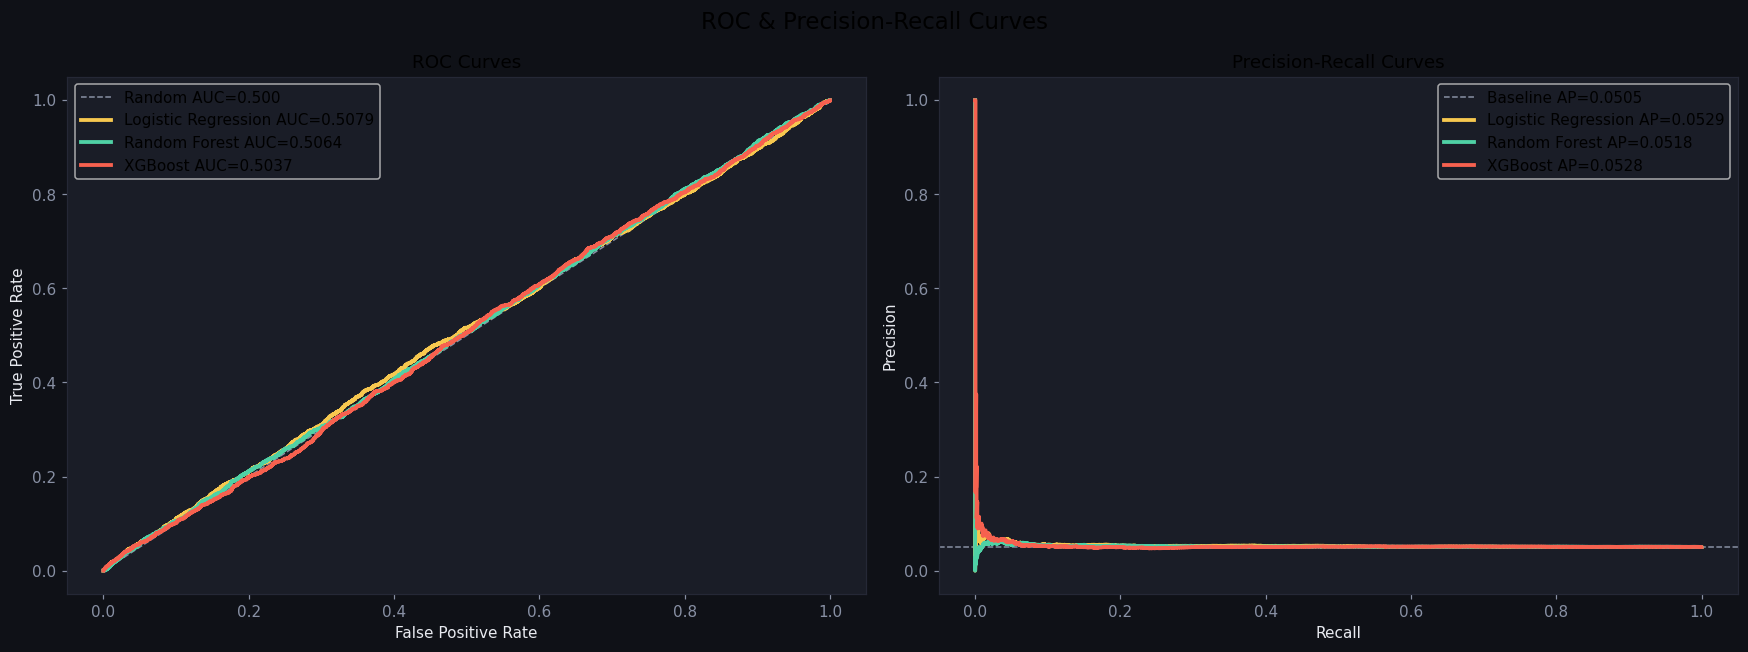

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("ROC & Precision-Recall Curves", fontsize=15)

model_data = [
    ("Logistic Regression", lr_proba, DARK["gold"]),
    ("Random Forest", rf_proba, DARK["green"]),
    ("XGBoost", xgb_proba, DARK["red"]),
]

# ROC
axes[0].plot([0,1], [0,1], "--", color=DARK["sub"], lw=1, label="Random AUC=0.500")
for name, proba, clr in model_data:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, color=clr, lw=2.5, label=f"{name} AUC={auc:.4f}")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves")
axes[0].legend()

# Precision-Recall
axes[1].axhline(y_test.mean(), color=DARK["sub"], ls="--", lw=1, label=f"Baseline AP={y_test.mean():.4f}")
for name, proba, clr in model_data:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(rec, prec, color=clr, lw=2.5, label=f"{name} AP={ap:.4f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves")
axes[1].legend()

plt.tight_layout()
plt.show()

## Confusion Matrices

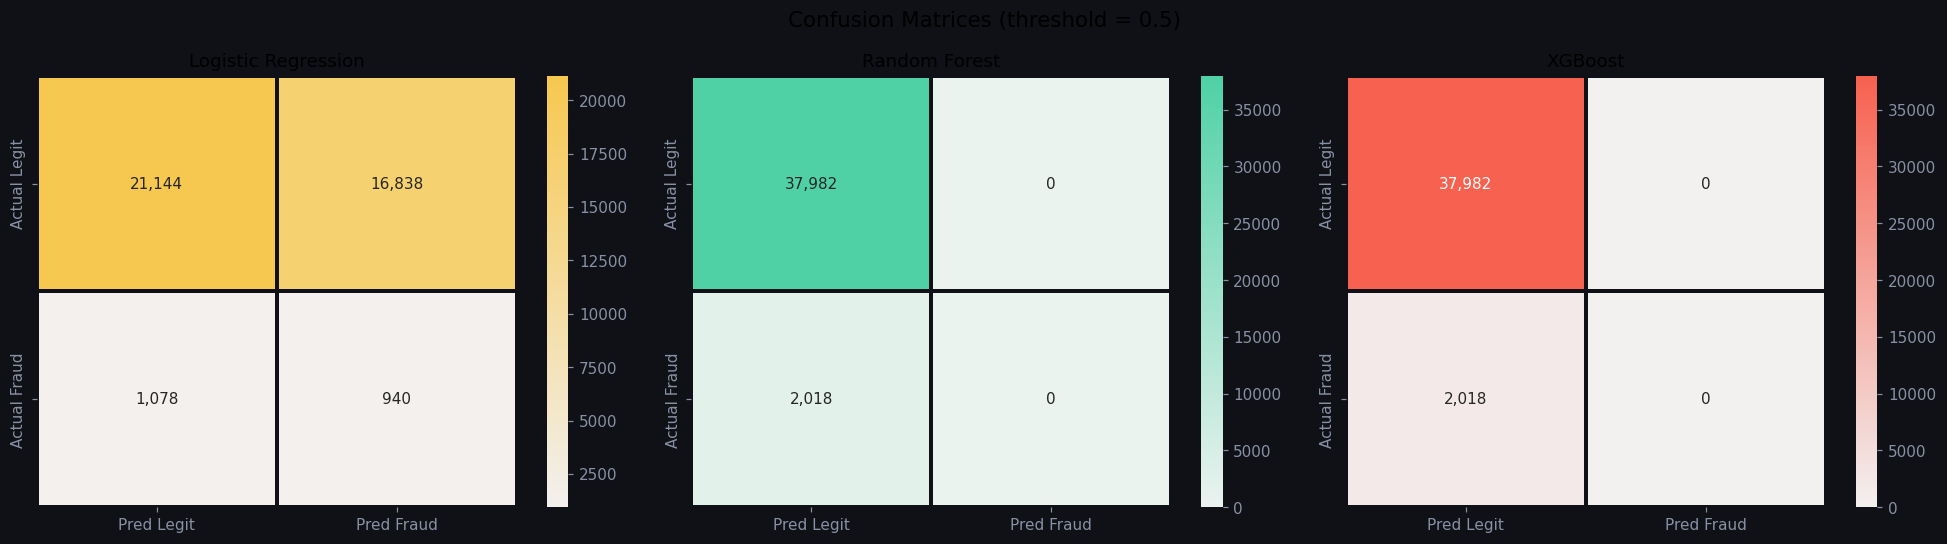

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices (threshold = 0.5)", fontsize=14)

for ax, (name, preds, clr) in zip(axes, [
    ("Logistic Regression", lr_preds, DARK["gold"]),
    ("Random Forest", rf_preds, DARK["green"]),
    ("XGBoost", xgb_preds, DARK["red"]),
]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt=",", cmap=sns.light_palette(clr, as_cmap=True),
                xticklabels=["Pred Legit", "Pred Fraud"],
                yticklabels=["Actual Legit", "Actual Fraud"],
                linewidths=1.5, linecolor=DARK["bg"], ax=ax)
    ax.set_title(name)

plt.tight_layout()
plt.show()

## Save models

In [17]:
joblib.dump(lr_model, "models/logistic_regression_model.pkl")
joblib.dump(rf_model, "models/random_forest_model.pkl")
joblib.dump(xgb_model, "models/xgboost_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")
print("Models saved")

Models saved
